In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor


In [6]:
df = pd.read_csv(r"C:\Users\AHMAD\Desktop\data final project colledge\Depi M5\data\analysis\engineered_time_series.csv")

df.head()

,d,sales,date,wm_yr_wk,wday,month,year,snap_CA,quarter,is_weekend,...,event_type_1_National,event_type_1_None,event_type_1_Religious,event_type_1_Sporting,event_name_2_Easter,event_name_2_Father's day,event_name_2_None,event_name_2_OrthodoxEaster,event_type_2_None,event_type_2_Religious
0,d_29,0,2011-02-26,11105,1,2,2011,0,1,1,...,False,True,False,False,False,False,True,False,True,False
1,d_30,0,2011-02-27,11105,2,2,2011,0,1,1,...,False,True,False,False,False,False,True,False,True,False
2,d_31,0,2011-02-28,11105,3,2,2011,0,1,0,...,False,True,False,False,False,False,True,False,True,False
3,d_32,0,2011-03-01,11105,4,3,2011,1,1,0,...,False,True,False,False,False,False,True,False,True,False
4,d_33,0,2011-03-02,11105,5,3,2011,1,1,0,...,False,True,False,False,False,False,True,False,True,False


In [7]:
y = df["sales"]

# Features
X = df.drop(columns=["sales", "d", "date"])

# Convert boolean columns to integers
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [8]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [9]:
# Walk-forward cross-validation object: each fold trains on an expanding
# window of past data and validates on the next chronological chunk.
tscv = TimeSeriesSplit(n_splits=5)

In [10]:

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [11]:
def cv_evaluate(model, X, y, splitter, model_name):
    mae_scores = []
    mse_scores = []
    rmse_scores = []
    r2_scores = []

    print(f"\n{model_name}")

    for fold, (train_idx, val_idx) in enumerate(splitter.split(X), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        mae, mse, rmse, r2 = evaluate_model(y_val, preds)

        mae_scores.append(mae)
        mse_scores.append(mse)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        print(f"Fold {fold}")
        print(f"  MAE : {mae:.2f}")
        print(f"  MSE : {mse:.2f}")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  R²  : {r2:.3f}")

    print("\nAverage CV Performance")
    print(f"MAE : {np.mean(mae_scores):.2f}")
    print(f"MSE : {np.mean(mse_scores):.2f}")
    print(f"RMSE: {np.mean(rmse_scores):.2f}")
    print(f"R²  : {np.mean(r2_scores):.3f}")

    return (
        np.mean(mae_scores),
        np.mean(mse_scores),
        np.mean(rmse_scores),
        np.mean(r2_scores),
    )

In [12]:
_ = cv_evaluate(LinearRegression(), X_train, y_train, tscv, "Linear Regression")

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae, lr_mse, lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred)
print("Linear Regression (held-out test)")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)



Linear Regression
Fold 1
  MAE : 207.57
  MSE : 51524.74
  RMSE: 226.99
  R²  : -3.924
Fold 2
  MAE : 48.79
  MSE : 4653.56
  RMSE: 68.22
  R²  : 0.335
Fold 3
  MAE : 53.23
  MSE : 7248.06
  RMSE: 85.14
  R²  : 0.567
Fold 4
  MAE : 35.55
  MSE : 3490.09
  RMSE: 59.08
  R²  : 0.423
Fold 5
  MAE : 36.50
  MSE : 2785.86
  RMSE: 52.78
  R²  : 0.456

Average CV Performance
MAE : 76.33
MSE : 13940.46
RMSE: 98.44
R²  : -0.428
Linear Regression (held-out test)
MAE: 28.023981706862468
MSE: 1829.4404999323363
RMSE: 42.77195927161084
R2: 0.46598105267256384


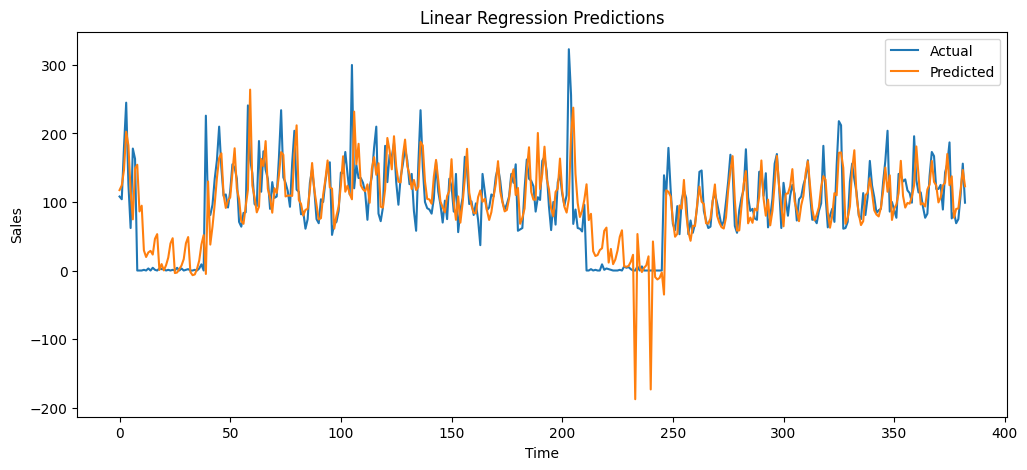

In [13]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")

plt.plot(lr_pred, label="Predicted")

plt.title("Linear Regression Predictions")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [14]:
param_grid_dt = {
    "max_depth": [5, 8, 10, 15],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print("Decision Tree best params:", dt_grid.best_params_)
print("Decision Tree best CV MAE:", -dt_grid.best_score_)

_ = cv_evaluate(clone(dt_grid.best_estimator_), X_train, y_train, tscv, "Decision Tree (tuned)")

dt = dt_grid.best_estimator_
dt_pred = dt.predict(X_test)
dt_mae, dt_mse, dt_rmse, dt_r2 = evaluate_model(y_test, dt_pred)

print("Decision Tree (held-out test)")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R2:", dt_r2)

Decision Tree best params: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Decision Tree best CV MAE: 56.804427826650326

Decision Tree (tuned)
Fold 1
  MAE : 76.90
  MSE : 9893.77
  RMSE: 99.47
  R²  : 0.054
Fold 2
  MAE : 56.59
  MSE : 6597.08
  RMSE: 81.22
  R²  : 0.058
Fold 3
  MAE : 68.20
  MSE : 12279.74
  RMSE: 110.81
  R²  : 0.267
Fold 4
  MAE : 46.37
  MSE : 3918.37
  RMSE: 62.60
  R²  : 0.352
Fold 5
  MAE : 35.96
  MSE : 2202.02
  RMSE: 46.93
  R²  : 0.570

Average CV Performance
MAE : 56.80
MSE : 6978.20
RMSE: 80.21
R²  : 0.260
Decision Tree (held-out test)
MAE: 32.03950197912829
MSE: 1987.6736376550414
RMSE: 44.58333363102227
R2: 0.4197923443532052


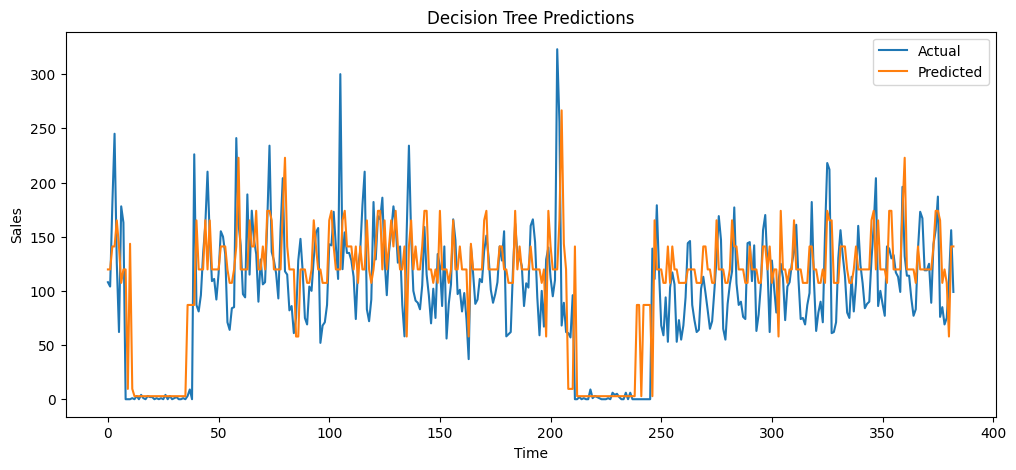

In [15]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")

plt.plot(dt_pred, label="Predicted")

plt.title("Decision Tree Predictions")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [16]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5],
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Random Forest best params:", rf_grid.best_params_)
print("Random Forest best CV MAE:", -rf_grid.best_score_)

_ = cv_evaluate(clone(rf_grid.best_estimator_), X_train, y_train, tscv, "Random Forest (tuned)")

rf = rf_grid.best_estimator_
rf_pred = rf.predict(X_test)
rf_mae, rf_mse, rf_rmse, rf_r2 = evaluate_model(y_test, rf_pred)

print("Random Forest (held-out test)")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest best CV MAE: 54.24069994392537

Random Forest (tuned)
Fold 1
  MAE : 77.08
  MSE : 9574.85
  RMSE: 97.85
  R²  : 0.085
Fold 2
  MAE : 52.82
  MSE : 5193.28
  RMSE: 72.06
  R²  : 0.258
Fold 3
  MAE : 64.81
  MSE : 11223.03
  RMSE: 105.94
  R²  : 0.330
Fold 4
  MAE : 40.53
  MSE : 2794.12
  RMSE: 52.86
  R²  : 0.538
Fold 5
  MAE : 35.95
  MSE : 2094.80
  RMSE: 45.77
  R²  : 0.591

Average CV Performance
MAE : 54.24
MSE : 6176.01
RMSE: 74.90
R²  : 0.361
Random Forest (held-out test)
MAE: 25.483501094054517
MSE: 1351.7681070792426
RMSE: 36.766399158460466
R2: 0.605414998957355


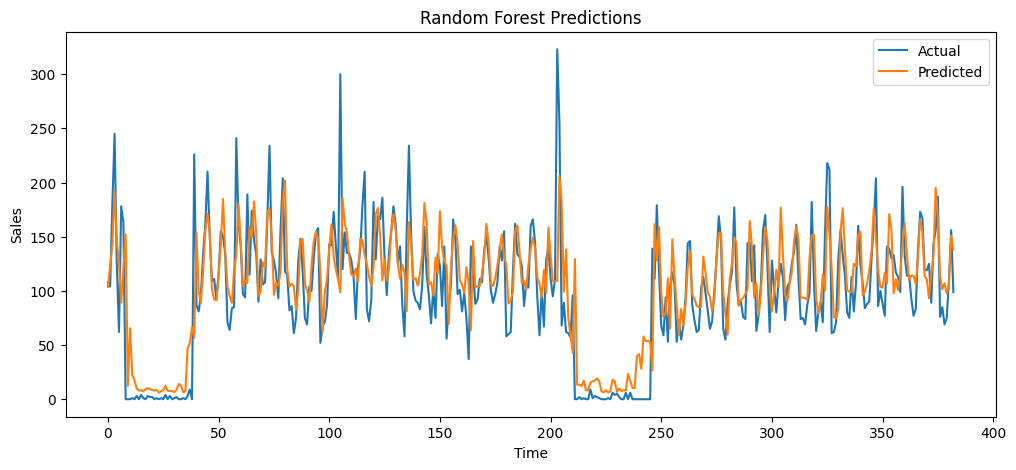

In [17]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")

plt.plot(rf_pred, label="Predicted")

plt.title("Random Forest Predictions")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [18]:
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0],
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
gb_grid.fit(X_train, y_train)
print("Gradient Boosting best params:", gb_grid.best_params_)
print("Gradient Boosting best CV MAE:", -gb_grid.best_score_)

_ = cv_evaluate(clone(gb_grid.best_estimator_), X_train, y_train, tscv, "Gradient Boosting (tuned)")

gb = gb_grid.best_estimator_
gb_pred = gb.predict(X_test)
gb_mae, gb_mse, gb_rmse, gb_r2 = evaluate_model(y_test, gb_pred)

print("Gradient Boosting (held-out test)")
print("MAE:", gb_mae)
print("MSE:", gb_mse)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Gradient Boosting best CV MAE: 53.31549869402422

Gradient Boosting (tuned)
Fold 1
  MAE : 70.72
  MSE : 8244.12
  RMSE: 90.80
  R²  : 0.212
Fold 2
  MAE : 54.01
  MSE : 5383.93
  RMSE: 73.38
  R²  : 0.231
Fold 3
  MAE : 64.77
  MSE : 10596.19
  RMSE: 102.94
  R²  : 0.368
Fold 4
  MAE : 40.44
  MSE : 2993.70
  RMSE: 54.71
  R²  : 0.505
Fold 5
  MAE : 36.64
  MSE : 2330.16
  RMSE: 48.27
  R²  : 0.545

Average CV Performance
MAE : 53.32
MSE : 5909.62
RMSE: 74.02
R²  : 0.372
Gradient Boosting (held-out test)
MAE: 27.404934789875952
MSE: 1515.0189160330253
RMSE: 38.92324390429227
R2: 0.5577616179640534


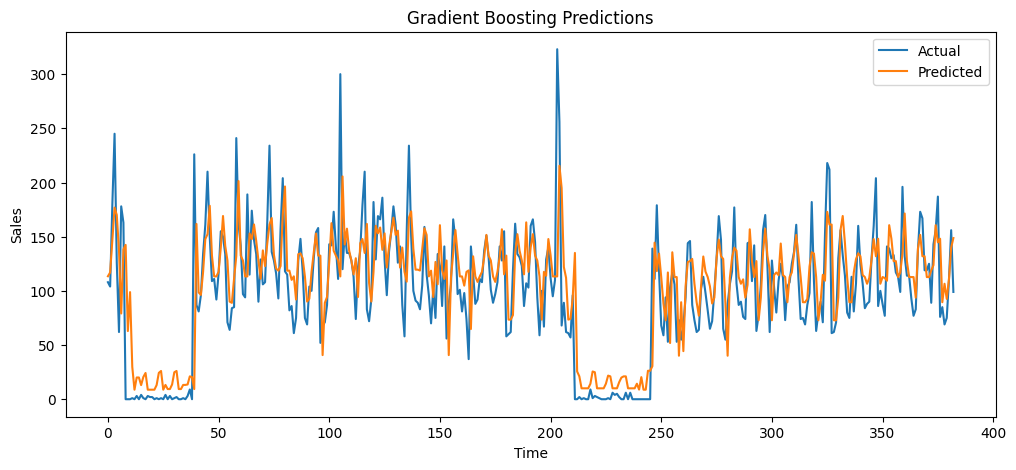

In [19]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")

plt.plot(gb_pred, label="Predicted")

plt.title("Gradient Boosting Predictions")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [20]:


param_grid_xgb = {
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
    }
xgb_grid = GridSearchCV(
        XGBRegressor(n_estimators=300, reg_alpha=0.1, reg_lambda=1.0,
                      random_state=42, objective="reg:squarederror"),
        param_grid_xgb, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
    )
xgb_grid.fit(X_train, y_train)
print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best CV MAE:", -xgb_grid.best_score_)

_ = cv_evaluate(clone(xgb_grid.best_estimator_), X_train, y_train, tscv, "XGBoost (tuned)")

# Step 1: use early stopping ONLY to find the right number of rounds —
# carve off a validation slice just for this purpose.
val_size = int(len(X_train) * 0.15)
X_fit, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_fit, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

xgb_early = XGBRegressor(
        n_estimators=1000, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
        objective="reg:squarederror", early_stopping_rounds=30, eval_metric="mae",
        **xgb_grid.best_params_
    )
xgb_early.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
best_n_estimators = xgb_early.best_iteration
print("Optimal number of rounds found via early stopping:", best_n_estimators)

    # Step 2: refit on the FULL training set with that fixed round count,
    # so XGBoost trains on the same data RF/GB got — no held-back 15%.
xgb = XGBRegressor(
        n_estimators=best_n_estimators, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, objective="reg:squarederror",
        **xgb_grid.best_params_
    )
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_mae, xgb_mse, xgb_rmse, xgb_r2 = evaluate_model(y_test, xgb_pred)

print("XGBoost (held-out test, trained on full data)")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)


XGBoost best params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8}
XGBoost best CV MAE: 52.00364456176758

XGBoost (tuned)
Fold 1
  MAE : 63.18
  MSE : 8150.06
  RMSE: 90.28
  R²  : 0.221
Fold 2
  MAE : 51.41
  MSE : 4953.44
  RMSE: 70.38
  R²  : 0.293
Fold 3
  MAE : 66.70
  MSE : 11588.79
  RMSE: 107.65
  R²  : 0.308
Fold 4
  MAE : 45.04
  MSE : 3530.79
  RMSE: 59.42
  R²  : 0.417
Fold 5
  MAE : 35.40
  MSE : 1946.92
  RMSE: 44.12
  R²  : 0.620

Average CV Performance
MAE : 52.35
MSE : 6034.00
RMSE: 74.37
R²  : 0.372
Optimal number of rounds found via early stopping: 270
XGBoost (held-out test, trained on full data)
MAE: 28.420677185058594
MSE: 1511.612548828125
RMSE: 38.87946178675992
R2: 0.5587559342384338


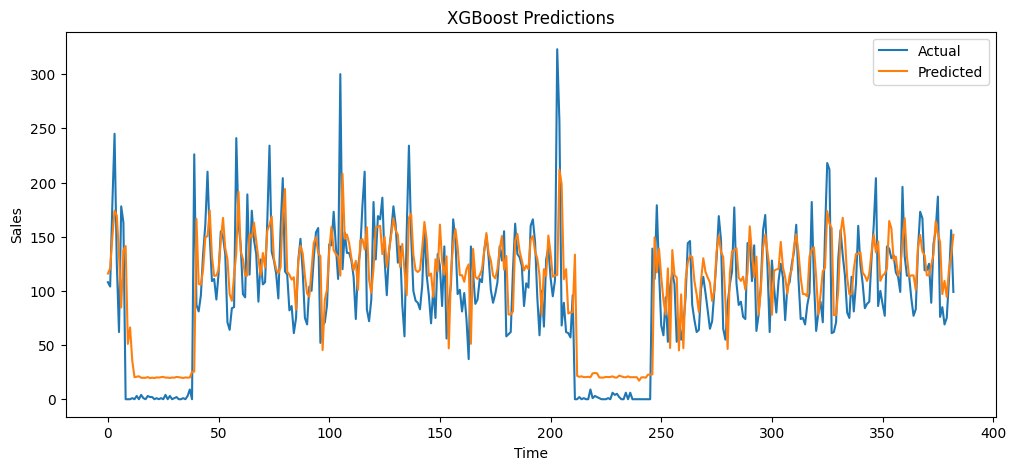

In [21]:

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.title("XGBoost Predictions")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [22]:
model_rows = [
    ("Linear Regression", lr_mae, lr_mse, lr_rmse, lr_r2),
    ("Decision Tree", dt_mae, dt_mse, dt_rmse, dt_r2),
    ("Random Forest", rf_mae, rf_mse, rf_rmse, rf_r2),
    ("Gradient Boosting", gb_mae, gb_mse, gb_rmse, gb_r2),
    ("XGBoost", xgb_mae, xgb_mse, xgb_rmse, xgb_r2),
]

fitted_models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

predictions = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}

results = pd.DataFrame(
    model_rows,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

results = results.sort_values("RMSE").reset_index(drop=True)

display(results)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,25.483501,1351.768107,36.766399,0.605415
1,XGBoost,28.420677,1511.612549,38.879462,0.558756
2,Gradient Boosting,27.404935,1515.018916,38.923244,0.557762
3,Linear Regression,28.023982,1829.440500,42.771959,0.465981
4,Decision Tree,32.039502,1987.673638,44.583334,0.419792


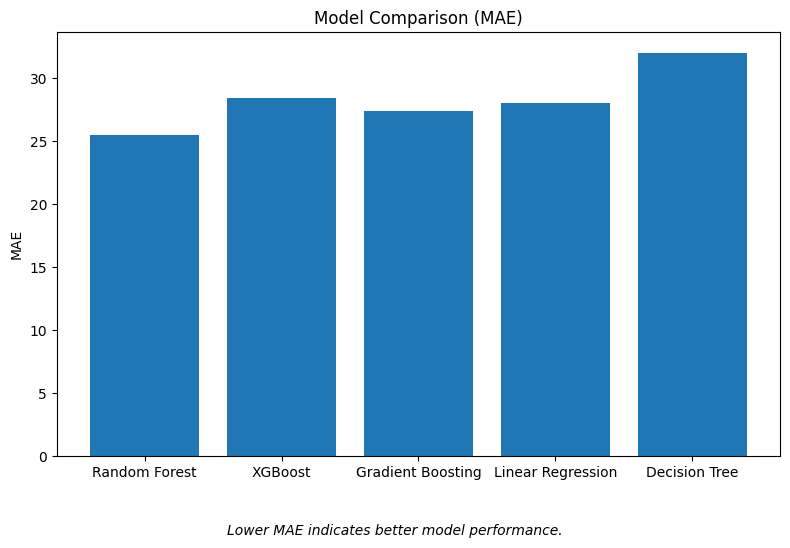

In [23]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["MAE"])

plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")

plt.figtext(
    0.5, -0.08,
    "Lower MAE indicates better model performance.",
    ha="center",
    fontsize=10,
    style="italic"
)

plt.tight_layout()
plt.show()

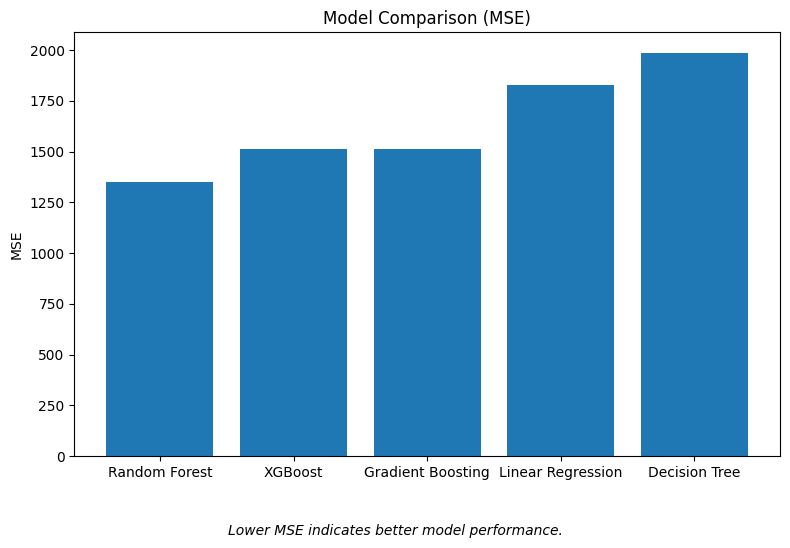

In [24]:


plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["MSE"])

plt.title("Model Comparison (MSE)")
plt.ylabel("MSE")

plt.figtext(
    0.5, -0.08,
    "Lower MSE indicates better model performance.",
    ha="center",
    fontsize=10,
    style="italic"
)

plt.tight_layout()
plt.show()

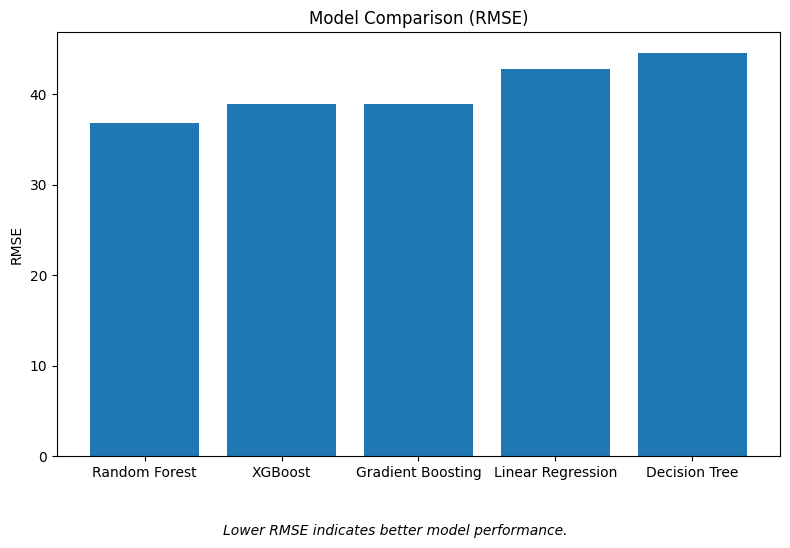

In [25]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")

plt.figtext(
    0.5, -0.08,
    "Lower RMSE indicates better model performance.",
    ha="center",
    fontsize=10,
    style="italic"
)

plt.tight_layout()
plt.show()

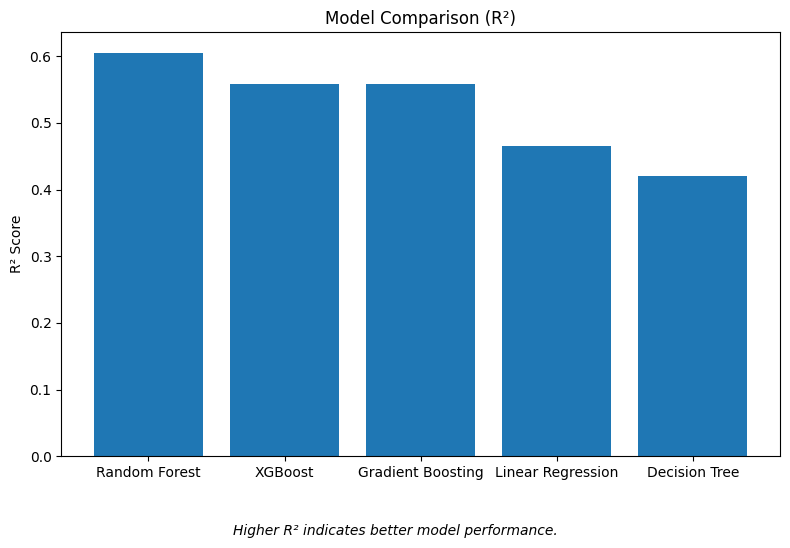

In [26]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")

plt.figtext(
    0.5, -0.08,
    "Higher R² indicates better model performance.",
    ha="center",
    fontsize=10,
    style="italic"
)

plt.tight_layout()
plt.show()

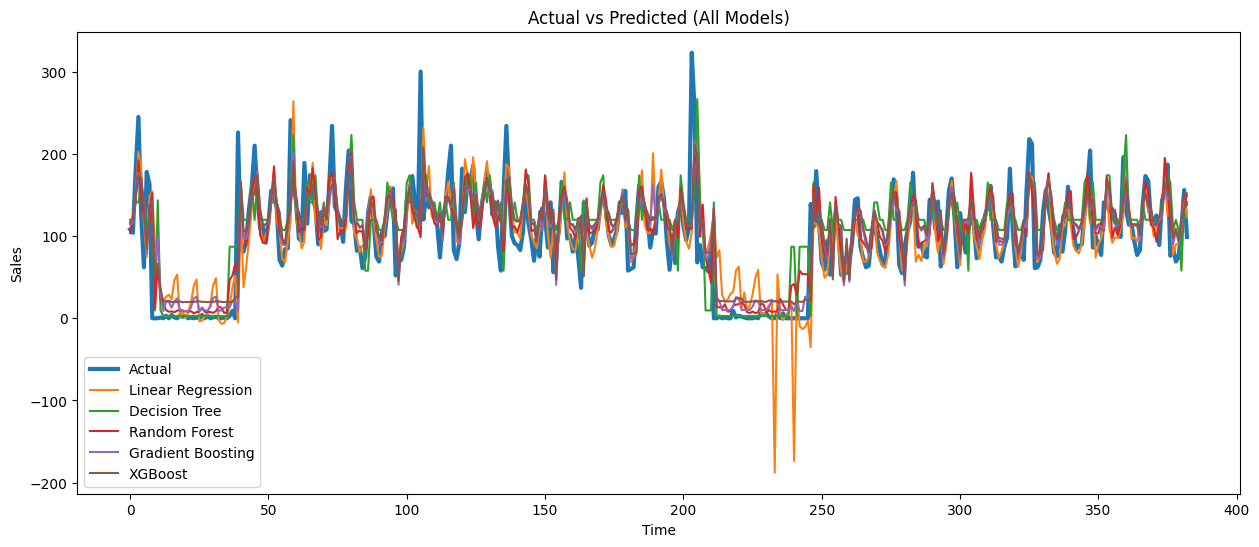

In [27]:
plt.figure(figsize=(15,6))
plt.plot(y_test.values, label="Actual", linewidth=3)
for name, preds in predictions.items():
    plt.plot(preds, label=name)
plt.title("Actual vs Predicted (All Models)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()


Best model on the held-out test set: Random Forest


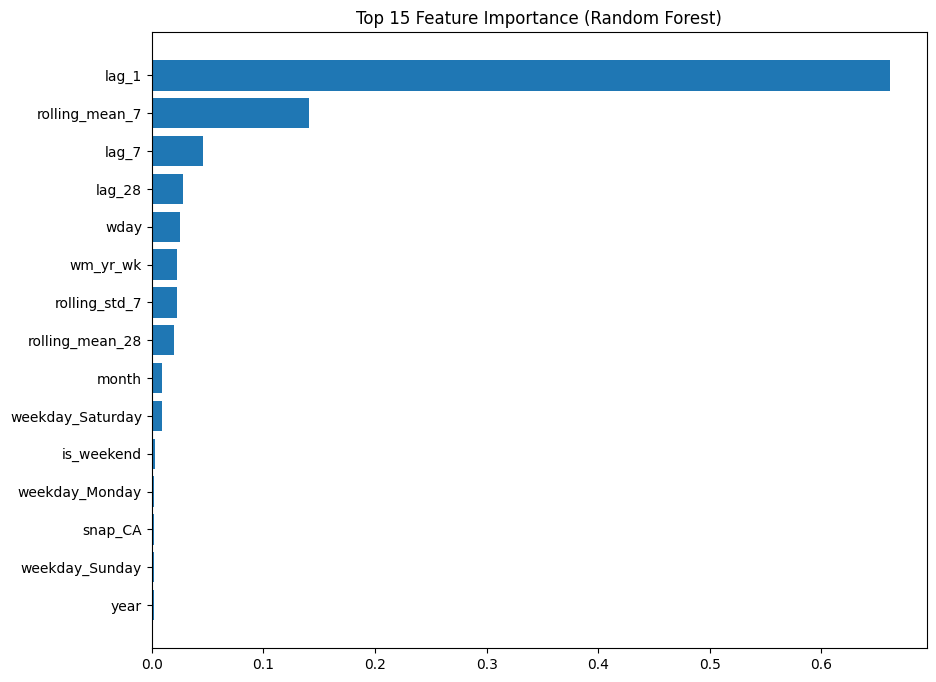

In [28]:
best_model_name = results.sort_values("RMSE").iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]
print("Best model on the held-out test set:", best_model_name)

if hasattr(best_model, "feature_importances_"):
    importance_source, source_name = best_model, best_model_name
else:
    importance_source, source_name = rf, "Random Forest"  # fallback if best model has no importances (e.g. Linear Regression)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_source.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
plt.barh(importance["Feature"][:15], importance["Importance"][:15])
plt.gca().invert_yaxis()
plt.title(f"Top 15 Feature Importance ({source_name})")
plt.show()

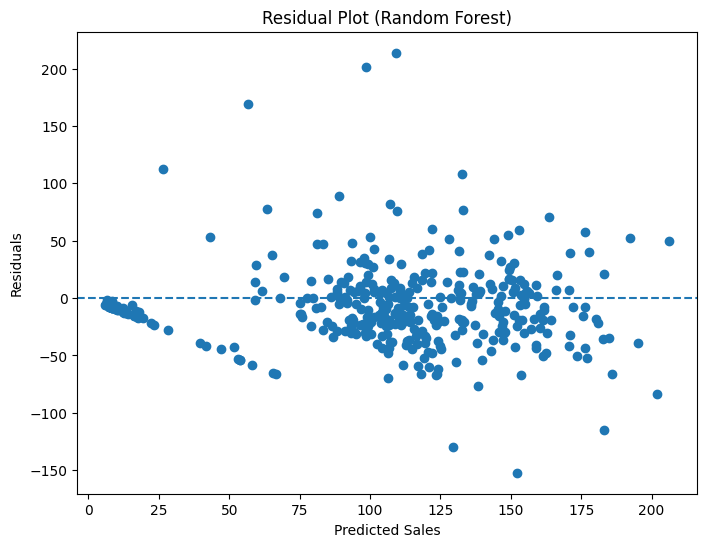

In [29]:
errors = y_test - best_pred

plt.figure(figsize=(8,6))
plt.scatter(best_pred, errors)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

In [30]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [31]:
joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']